In [1]:
import time
from typing import Any
from collections.abc import Sequence

import numpy as np
import scipy as sp
import pandas as pd

from sklearn.model_selection import ParameterGrid

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

from IPython.display import display, Audio

In [2]:
%load_ext line_profiler
%load_ext autoreload
%autoreload 2

In [3]:
# Change error handling for numpy
#np.seterr(all='raise', under='ignore')

In [4]:
from duet_opt import init_data, score_alpha_deltas, find_alpha_deltas, check_params, DATA
from source_generation import display_results
from duet_ms import DuetMS

In [5]:
# Setup parameter grid to search

# Options that don't really influence other parameters or should always be searched
base_options = {
    # Audio Lengths to try (in ms)
    # Original target was 96ms, must be multiple of 16ms
    # Due to memory constraints, we may not be able to go above 96ms on the real chip (looking into this now)
    # In theory, longer audio lengths should give better results, but take longer to compute and use more memory
    # This will influence min_bin_count and possibly others, but we still want to search it independently
    "audio_length": [96, 112, 128],  # [64, 80, 96, 112, 128, 144]

    # STFT window sizes to try
    # Must be power of 2, larger windows give better frequency resolution but worse time resolution
    # This will influence min_bin_count and possibly others, but we still want to search it independently
    "window": [128, 256],  # [64, 128, 256, 512, 1024]

    # Oversampling factors to try
    # Must be odd integers with 1 being no oversampling
    # Higher oversampling improves resolution in STFT but is much slower
    "oversample": [1],  # [1, 3, 5],  # higher is much, much, slower and not typically better

    # p and q weights for attenuation and delay estimators (from paper p.225)
    # p = 0, q = 0: the counting histogram proposed in the original DUET algorithm [13] - should not be used
    # p = 1, q = 0: motivated by the ML symmetric attenuation estimator [12] (default)
    # p = 1, q = 2: motivated by the ML delay estimator [12]
    # p = 2, q = 0: in order to reduce delay estimator bias [12]
    # p = 2, q = 2: for low signal-to-noise ratio or speech mixtures [14]
    # p = 0.5, q = 0: when sources are not equal power, as it prevents the dominant source from hiding the smaller source peaks
    "p": [0.5, 1, 2],  # [0.5, 1, 2]  # preliminary results suggest that p=0.5 is much better for our data, likely because sources are not equal power and we want to prevent the dominant source from hiding the smaller source peaks
    "q": [0, 2],       # [0, 2]       # preliminary results suggest that q=0 is much better for our data

    # Alpha conversion operations to try
    # "symmetric" is the original DUET operation, "log" is a logarithmic scaling
    # "none" is not recommended as it makes no sense
    "alpha_op": ["symmetric"],  # ["symmetric", "log"]

    # Big delay methods to try
    # "none" is the original DUET method (will not work in our system)
    # "diff" is a differential method
    "big_delay": ["diff"],

    # Delta smoothing parameters to try
    # Smoothing helps reduce noise in delta estimates and is especially important for big-delta
    # Tuples are (freq, time) smoothing kernel sizes; (1, 1) means no smoothing
    "delta_smoothing": [(3, 1), (3, 3)],  # (1, 1), (3, 1), (3, 3), (5, 1), (5, 3)

    # Delta smoothing modes to try
    # Can be "mean", "median", or "gaussian"
    "delta_smoothing_mode": ["mean"],  # ["mean", "median", "gaussian"]

    # Thresholds to try for peak picking
    # Lower thresholds include more data but may include more noise and will be slower
    "threshold": [0.1, 0.25, 0.35],  # [0.05, 0.1, 0.2, 0.25, 0.35, 0.5, 0.75]  # >=0.5 seems to always crash

    # Alpha max values to try, hardcoded for now
    "alpha_max": [1.5],  # TODO:
    # Delta max values to try, hardcoded for now
    "delta_max": [8.5],  # TODO: 8.5?

    # Convergence tolerances to try for mean-shift
    # Larger tolerances will converge faster but may be less accurate
    # A value of 1.0 means it will converge once reaching the nearest grid point
    # (but since seeds are initialized at grid points, this means they will not move at all)
    "convergence_tol": [0.25],  # [0.05, 0.1, 0.2, 0.25, 0.3, 0.5]
}

grid = [{
    **base_options,

    # Bandwidths to try for mean-shift
    # Single values are isotropic, tuples are (alpha_bandwidth, delta_bandwidth)
    # Bandwidths that are too small may lead to overfitting/noise, too large may miss sources
    # This is one of the most important parameters to tune and is likely anisotropic
    # This also effects grid size and thus memory usage and speed
    "bandwidth": [
        0.2, 0.3, 0.4, 0.75,
        # 0.1, 0.2, 0.25, 0.3, 0.4,
        # (0.1, 0.2), (0.1, 0.25), (0.1, 0.3), (0.1, 0.4),
        # (0.2, 0.1), (0.2, 0.25), (0.2, 0.3), (0.2, 0.4),
        # (0.25, 0.1), (0.25, 0.2), (0.25, 0.3), (0.25, 0.4),
        # (0.3, 0.1), (0.3, 0.2), (0.3, 0.25), (0.3, 0.4),
        # (0.4, 0.1), (0.4, 0.2), (0.4, 0.25), (0.4, 0.3),
    ],

    # TODO: time_bandwidth and frequency_bandwidth (these majorly influence min_bin_count)

    # Seed counts to try for mean-shift initialization
    # More seeds means that more unique peaks can possible be found (which may or may not be noise), but is slower
    # None means to use all possible unique peaks
    "seed_count": [10, 20],   # [8, 10, 12, 15, 20, 25, 35, 50, 75, 100] # None is slow and bad

    # Minimum bin counts to try for mean-shift seed selection
    # Larger will eliminate more seeds and be faster, but may miss some sources (but also may eliminate noise peaks)
    # A value of 1 means no elimination
    # Note that as bandwith increases, the size of bins increases and thus the bin count needs to increase to have the same effect
    "min_bin_count": [8, 10, 15],  # [1, 2, 5, 8, 10, 15, 20, 25, 50]  # in general, larger is much worse and only slightly faster (but there are others that are just as fast)

    # Max filter sizes to try for mean-shift seed selection
    # Must be None (for no filtering) or odd integers >1 for filtering
    # Remove possible seeds that are not local maxima within max_filter_size; this can help speed up results a lot by removing seeds
    # As this is increased, seed_count should be decreased or min_bin_count increased to prevent finding random local maxima that are not sources
    "max_filter_size": [None, 3],  # [None, 3, 5, (1, 3), (3, 1), (5, 1), (5, 3), (1, 5), (3, 5)]

    # Compute seeds with weights or not
    # Using weights may help find better seeds, but will require a dramatically different min_bin_count
    # (in my tests of a full audio sample, the `min_bin_count` changed from 50 to 600 when using weights to capture the same number of seeds)
    "compute_seeds_using_weights": [True],  # TODO: need a separate grid search for when `False`
}]
param_grid = ParameterGrid(grid)

len(param_grid)

10368

In [6]:
init_data()

['plastic_crumpling: s=36541, a=1.26, d=-3.60, rms=-21.07', 'plastic_crumpling: s=6497, a=1.19, d=-4.43, rms=-23.66']
['chewing_gum: s=47725, a=1.11, d=-6.50, rms=-39.43', 'plastic_crumpling: s=43390, a=1.06, d=-4.28, rms=-25.05']
['chewing_gum: s=20013, a=1.51, d=-0.65, rms=-38.56', 'plastic_crumpling: s=41998, a=0.66, d=-6.00, rms=-30.56']
['human_breathing: s=44720, a=0.72, d=-0.75, rms=-21.74', 'plastic_crumpling: s=18296, a=0.87, d=5.35, rms=-29.75']
['human_breathing: s=33517, a=1.24, d=6.61, rms=-29.44', 'human_breathing: s=26728, a=0.75, d=1.07, rms=-27.71']
['chewing_gum: s=28877, a=1.04, d=-5.77, rms=-33.76', 'water_drops: s=39042, a=1.28, d=3.92, rms=-14.99']
['typing: s=33606, a=1.44, d=-0.74, rms=-21.32', 'chewing_gum: s=12508, a=0.79, d=7.26, rms=-26.66']
['chewing_gum: s=44642, a=0.66, d=6.49, rms=-38.05', 'human_breathing: s=32612, a=0.77, d=5.75, rms=-23.12']
['clearing_throat: s=31796, a=1.08, d=3.57, rms=-25.05', 'basketball_dribbling: s=27477, a=0.78, d=6.12, rms=-3

In [ ]:
# Study one of the data samples in depth
ind = 1
DATA[ind]

(array([[ 1.07041685e-01,  2.27756134e-01, -7.06183869e-02, ...,
          2.53120758e-04,  7.63758418e-03,  9.99324864e-03],
        [-2.78598867e-01, -8.57947243e-02,  1.01944506e-01, ...,
         -5.93469191e-03, -5.10166144e-03, -1.10567523e-02]],
       shape=(2, 2395)),
 [1.1072091692537127, 1.0631187863860116],
 [-6.500876162214521, -4.277425705748167],
 [array([[-0.0016555 , -0.00293617, -0.00204012, ...,  0.00072683,
           0.00106828,  0.00181944],
         [-0.00538273, -0.00584784, -0.00114467, ...,  0.00233152,
          -0.00034466,  0.001374  ]], shape=(2, 2400)),
  array([[ 0.10348104, -0.04465197, -0.22255774, ...,  0.00989325,
           0.02975519,  0.01801853],
         [ 0.01656311,  0.21690199,  0.1320482 , ..., -0.0115893 ,
           0.00658335,  0.00441251]], shape=(2, 2402))])

In [ ]:
# Allows for displaying results for a single sample or sub-sample with given parameters
def display_params_2(d, params: dict, sub: int = -1, fs: int = 16000):
    colors = ['blue', 'orange', 'green', 'red', 'purple']
    color = None if sub == -1 else colors[sub % len(colors)]
    x = d[0] if sub == -1 else d[3][sub]
    params = params.copy()
    audio_length = params.pop("audio_length")
    x = x[:, :audio_length*fs//1000]
    duet = DuetMS(fs, **params)
    xx = duet._normalize_data(x)
    tf, tf_weights, alpha, delta = duet._compute_all(xx)
    alpha_peaks, delta_peaks = duet._find_peaks(tf_weights, alpha, delta)
    alpha_real = duet._convert_atn_to_alpha(np.array(d[1]))
    delta_real = d[2]
    if sub != -1:
        alpha_real = [alpha_real[sub]]
        delta_real = [delta_real[sub]]
    sns.heatmap(abs(tf[0]), norm=LogNorm(), cmap='viridis')
    plt.figure()
    display_results(alpha, delta, tf_weights, alpha_peaks, delta_peaks, alpha_real, delta_real, color=color)
    #return score_alpha_deltas((alpha_real, delta_real), (alpha_peaks, delta_peaks))


In [ ]:
# Start of W-disjoint orthogonality computation
duet = DuetMS(16000, window=256)
tfs = [duet._construct_spectrogram(s) for s in DATA[ind][3]]
mask = abs(tfs[0]) > abs(tfs[1])
s_hat = duet._demix(mask-ish, tfs)
# TODO: compute D/d according to 8.5 in paper

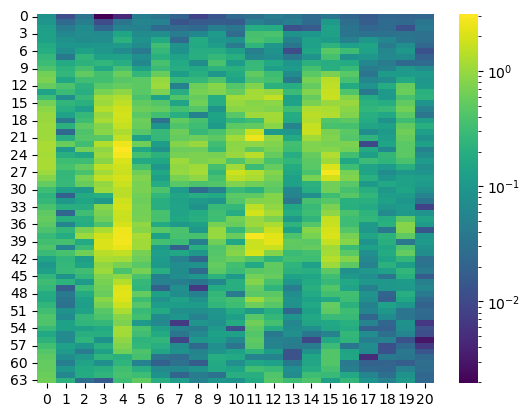

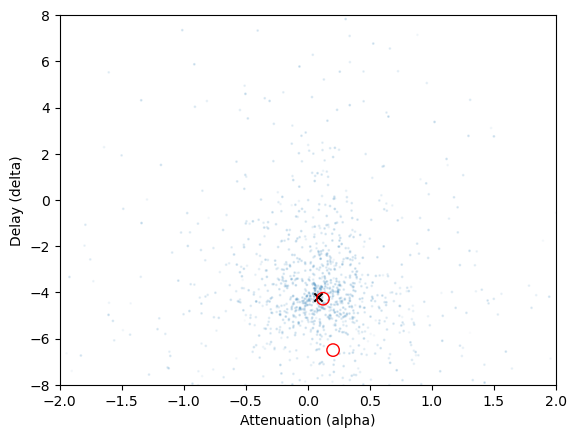

In [66]:
display_params_2(DATA[ind], param_grid[0])

In [67]:
DATA[ind][0]

array([[ 1.07041685e-01,  2.27756134e-01, -7.06183869e-02, ...,
         2.53120758e-04,  7.63758418e-03,  9.99324864e-03],
       [-2.78598867e-01, -8.57947243e-02,  1.01944506e-01, ...,
        -5.93469191e-03, -5.10166144e-03, -1.10567523e-02]],
      shape=(2, 2395))

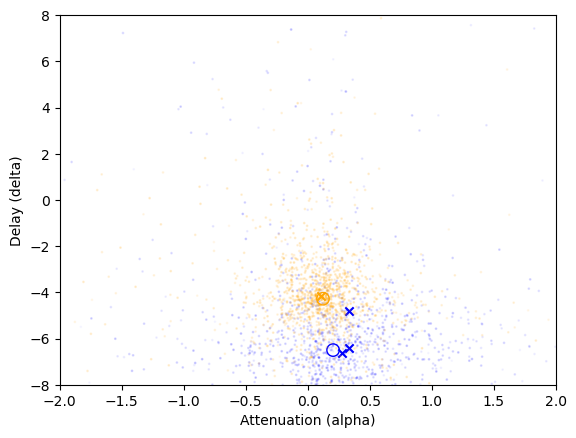

In [62]:
display_params_2(DATA[ind], param_grid[0], sub=0)
display_params_2(DATA[ind], param_grid[0], sub=1)

In [7]:
for i in range(len(DATA)):
    print(f"Audio {i}:")
    display(Audio(DATA[i][0], rate=16000))

Audio 0:


Audio 1:


Audio 2:


Audio 3:


Audio 4:


Audio 5:


Audio 6:


Audio 7:


Audio 8:


Audio 9:


In [8]:
def display_params(d, params: dict, fs: int = 16000):
    """
    Display results for given data and DUET parameters.
    """
    x = d[0]
    params = params.copy()
    audio_length = params.pop("audio_length")
    x = x[:, :audio_length*fs//1000]
    duet = DuetMS(fs, **params)
    xx = duet._normalize_data(x)
    _, tf_weights, alpha, delta = duet._compute_all(xx)
    alpha_peaks, delta_peaks = duet._find_peaks(tf_weights, alpha, delta)
    alpha_real = duet._convert_atn_to_alpha(np.array(d[1]))
    delta_real = d[2]
    display_results(alpha, delta, tf_weights, alpha_peaks, delta_peaks, alpha_real, delta_real)
    return score_alpha_deltas((alpha_real, delta_real), (alpha_peaks, delta_peaks))

def compare_subsets(masks, param_grid: Sequence[dict], scores, simplify_with_bool=False):
    """
    Compares two or more subsets of the results. masks is either a list of booleans or
    categorical values that indicate which subset each result belongs to. param_grid is
    the list of parameter combinations corresponding to each result, and scores is the
    list of scores corresponding to each result. The function will print out the mean
    and median scores for each subset, and highlight any major differences in parameter
    distributions across subsets.
    """
    param_keys = param_grid[0].keys()

    masks = np.array(masks)
    uniques = set(masks)
    overall_param_counts: dict[Any, dict[str, dict[str, int]]] = {}
    for value in uniques:
        mask = masks == value
        subset_indices = np.where(mask)[0]
        subset_params = [param_grid[i] for i in subset_indices]
        subset_scores = scores[subset_indices]
        count = len(subset_scores)
        mean_score = np.nanmean(subset_scores)
        med_score = np.nanmedian(subset_scores)
        print(f"Subset {value}: {count}, mean: {mean_score:.2f}, median: {med_score:.2f}")
        # Compute histogram of params in this subset
        param_counts = {}
        for params in subset_params:
            for key, val in params.items():
                if val not in param_counts.setdefault(key, {}):
                    param_counts[key][val] = 0
                param_counts[key][val] += 1
        overall_param_counts[value] = param_counts
    
    for key in param_keys:
        values = set(item for value in uniques for item in overall_param_counts[value][key].keys())
        value_counts = [overall_param_counts[value][key] for value in uniques]
        base = {k: round(value_counts[0].get(k, 0)/sum(value_counts[0].values()) * 100, 1) for k in values}
        
        # Eliminate any params that are just a single value across all subsets
        # Eliminate any params that are roughly the same across both subsets
        if len(values) == 1 or all(base == {k: round(val_counts.get(k, 0)/sum(val_counts.values()) * 100, 1) for k in values} for val_counts in value_counts[1:]):
            for value in uniques:
                overall_param_counts[value].pop(key)
        
    # Compare distributions of params across subsets and highlight any major differences
    if simplify_with_bool and len(uniques) == 2:
        uniques = [True] if True in uniques else [uniques.pop()]
    for key in overall_param_counts[next(iter(uniques))].keys():
        print(f"\nParameter: {key}")
        for value in uniques:
            if len(uniques) != 1:
                print(f"  Subset {value}:")
            param_counts = overall_param_counts[value][key]
            total = sum(param_counts.values())
            for val, count in param_counts.items():
                percent = count / total * 100
                print(f"    Value {val}: {count} ({percent:.1f}%)")

In [ ]:
########## Run Param Search ##########
# Run parameter search single-threaded (use the script to run multi-threaded)
# Prints progress every 1000 evaluations with estimated remaining time and best score so far
scores_list = []
times_list = []
overall_start = time.time()

for i, params in enumerate(param_grid):
    if i % 1000 == 0 and i > 0:
        elapsed = time.time() - overall_start
        perc = i / len(param_grid)
        per = elapsed / i * 1000
        print(f"Evaluating {i}/{len(param_grid)} {perc:.1%}; "
              f"{round(per)}ms per eval; "
              f"est remaining {per*(len(param_grid)-i)/(60*1000):.1f} min; "
              f"best so far: {min(s['custom'] for s in scores_list):.2f}")
    score, elapsed = check_params(params)
    scores_list.append(score)
    times_list.append(elapsed)

elapsed = time.time() - overall_start
per = elapsed / len(param_grid) * 1000
print(f"Done; {round(per)}ms per eval; "
      f"total time: {elapsed/60:.1f} min; "
      f"best score: {min(s['custom'] for s in scores_list):.2f}")

# TODO: need to fix this for new setup
# scores = np.array(scores_list)
# scores_orig = scores.copy()
# scores[scores == float('inf')] = np.nan  # remove infinite scores
times = np.array(times_list)
#times[times > 0.5] = np.nan

Evaluating 1000/10368 9.6%; 13ms per eval; est remaining 2.0 min; best so far: 2.44
Evaluating 2000/10368 19.3%; 14ms per eval; est remaining 1.9 min; best so far: 2.44
Evaluating 3000/10368 28.9%; 13ms per eval; est remaining 1.6 min; best so far: 1.67
Evaluating 4000/10368 38.6%; 14ms per eval; est remaining 1.5 min; best so far: 1.67
Evaluating 5000/10368 48.2%; 14ms per eval; est remaining 1.2 min; best so far: 1.67
Evaluating 6000/10368 57.9%; 14ms per eval; est remaining 1.0 min; best so far: 1.67
Evaluating 7000/10368 67.5%; 14ms per eval; est remaining 0.8 min; best so far: 1.67
Evaluating 8000/10368 77.2%; 14ms per eval; est remaining 0.6 min; best so far: 1.67
Evaluating 9000/10368 86.8%; 14ms per eval; est remaining 0.3 min; best so far: 1.67
Evaluating 10000/10368 96.5%; 14ms per eval; est remaining 0.1 min; best so far: 1.67
Done; 14ms per eval; total time: 2.5 min; best score: 1.67


In [ ]:
########## Load CSV Data ##########
# Read results from CSV and analyze
results = pd.read_csv("duet_opt_results.csv")
scores = results['score']  # TODO: need to fix this for new setup
scores_orig = scores.copy()
scores[scores == float('inf')] = np.nan  # remove infinite scores
times = results['time']
#times[times > 0.5] = np.nan  # remove massive time outliers

# Get the parameter grid from the results CSV by taking all columns that are not "score" or "time"
score_columns = results.columns[results.columns.str.startswith("score")]
param_grid = results.drop(columns=[*score_columns, 'time']).to_dict(orient='records')
# Deserialize any tuple columns in param_grid
def int_or_float(x: str):
    x = x.strip()
    return int(x) if x.isdigit() else float(x)
for params in param_grid:
    for key, val in params.items():
        if isinstance(val, str) and val.startswith('(') and val.endswith(')'):
            try:
                params[key] = tuple(map(int_or_float, val[1:-1].split(',')))
            except ValueError:
                pass


Subset False: 10368, mean: 4.20, median: 3.63


(np.int64(2671), 10368)

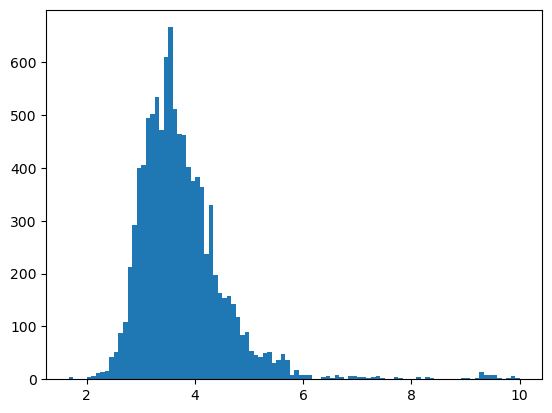

In [ ]:
# Display basic info
# TODO: new to fix this for new setup
scores = np.array([s['custom'] for s in scores_list])
times = np.array(times_list)
compare_subsets(np.isnan(scores), param_grid, scores)  # check which parameters are associated with failed runs (NaN scores)
plt.hist(scores, bins=100, range=(np.nanmin(scores), min(np.nanmax(scores), 10))) # plot overall distribution of scores (lower is better)
np.argmin(scores), len(scores) # best score and total evaluations

Value	Score min max median mean std	Time min max median mean std
0	     1.67 12.10 3.46 3.53 0.68       0.60 13.98 1.26 1.40 0.68
3	     2.16 63.47 3.92 4.87 5.28       0.47 12.13 0.88 0.95 0.38


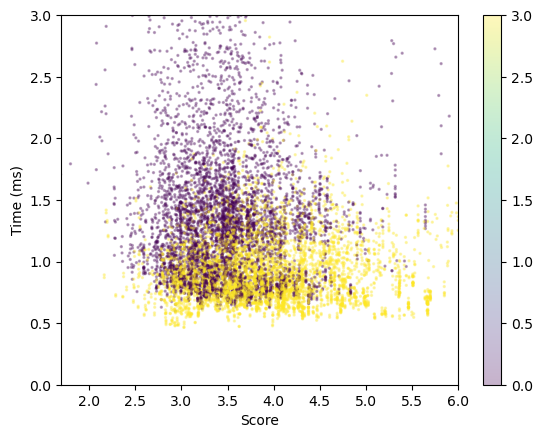

In [12]:
# Analyze parameter effects on score and time
parameter = "max_filter_size"  # change this to analyze different parameters (for "bandwidth", use either "bandwidth_alpha" or "bandwidth_delta")

# Get the values for the selected parameter, with special cases for bandwidth and delta_smoothing
if parameter == "bandwidth_alpha":
    def conv_param(x): return x if isinstance(x, float) else x[0]
    parameter = "bandwidth"
elif parameter == "bandwidth_delta":
    def conv_param(x): return x if isinstance(x, float) else x[1]
    parameter = "bandwidth"
elif parameter == "delta_smoothing":
    delta_smoothing_value_map = {(1, 1): 1, (3, 1): 2, (3, 3): 3, (5, 1): 4, (5, 3): 5}
    def conv_param(x): return delta_smoothing_value_map[x]
elif parameter == "max_filter_size":
    def conv_param(x): return 0 if x is None else x  # TODO: support tuple filter sizes
else:
    def conv_param(x): return x
values = np.array([conv_param(x[parameter]) for x in param_grid])[:len(scores)]  # trim to length of scores in case there are extra rows not computed

plt.scatter(scores, times[:len(scores)]*1000, alpha=0.3, s=2, c=values)
plt.colorbar()
plt.xlabel("Score")
plt.ylabel("Time (ms)")
plt.xlim(1.7, 6)
plt.ylim(0, 3)
print("Value\tScore min max median mean std\tTime min max median mean std")
for v in np.unique(values):
    s = scores[values == v]
    t = times[values == v]*1000
    print(f"{v}\t     {np.nanmin(s):.2f} {np.nanmax(s):.2f} {np.nanmedian(s):.2f} {np.nanmean(s):.2f} {np.nanstd(s):.2f}       {np.nanmin(t):.2f} {np.nanmax(t):.2f} {np.nanmedian(t):.2f} {np.nanmean(t):.2f} {np.nanstd(t):.2f}")


In [78]:
# Print out the worst parameter sets
# Is there a pattern? if so, remove those parameters from the grid
bad_score = np.nanpercentile(scores, 90)
compare_subsets(scores >= bad_score, param_grid, scores)
bad_score

Subset False: 77760, mean: 4.26, median: 3.84
Subset True: 8640, mean: 71.88, median: 52.12

Parameter: window
  Subset False:
    Value 128: 27086 (34.8%)
    Value 256: 25958 (33.4%)
    Value 512: 24716 (31.8%)
  Subset True:
    Value 256: 2842 (32.9%)
    Value 512: 4084 (47.3%)
    Value 128: 1714 (19.8%)

Parameter: threshold
  Subset False:
    Value 0.1: 25911 (33.3%)
    Value 0.25: 25918 (33.3%)
    Value 0.35: 25931 (33.3%)
  Subset True:
    Value 0.1: 2889 (33.4%)
    Value 0.25: 2882 (33.4%)
    Value 0.35: 2869 (33.2%)

Parameter: seed_count
  Subset False:
    Value 10: 43200 (55.6%)
    Value 20: 34560 (44.4%)
  Subset True:
    Value 20: 8640 (100.0%)

Parameter: q
  Subset False:
    Value 0: 39192 (50.4%)
    Value 2: 38568 (49.6%)
  Subset True:
    Value 0: 4008 (46.4%)
    Value 2: 4632 (53.6%)

Parameter: p
  Subset False:
    Value 0.5: 26159 (33.6%)
    Value 1: 25864 (33.3%)
    Value 2: 25737 (33.1%)
  Subset True:
    Value 0.5: 2641 (30.6%)
    Value 1: 2

np.float64(14.27439340750726)

In [79]:
# Print out the slowest parameter sets
# Is there a pattern? if so, remove those parameters from the grid
slow_time = np.nanpercentile(times, 90)
compare_subsets(times >= slow_time, param_grid, scores)
slow_time

Subset False: 77760, mean: 11.05, median: 3.95
Subset True: 8640, mean: 10.76, median: 4.47

Parameter: window
  Subset False:
    Value 256: 25965 (33.4%)
    Value 512: 25114 (32.3%)
    Value 128: 26681 (34.3%)
  Subset True:
    Value 128: 2119 (24.5%)
    Value 256: 2835 (32.8%)
    Value 512: 3686 (42.7%)

Parameter: threshold
  Subset False:
    Value 0.1: 24743 (31.8%)
    Value 0.25: 26194 (33.7%)
    Value 0.35: 26823 (34.5%)
  Subset True:
    Value 0.1: 4057 (47.0%)
    Value 0.25: 2606 (30.2%)
    Value 0.35: 1977 (22.9%)

Parameter: seed_count
  Subset False:
    Value 10: 42674 (54.9%)
    Value 20: 35086 (45.1%)
  Subset True:
    Value 10: 526 (6.1%)
    Value 20: 8114 (93.9%)

Parameter: q
  Subset False:
    Value 0: 40083 (51.5%)
    Value 2: 37677 (48.5%)
  Subset True:
    Value 0: 3117 (36.1%)
    Value 2: 5523 (63.9%)

Parameter: p
  Subset False:
    Value 0.5: 21835 (28.1%)
    Value 1: 27292 (35.1%)
    Value 2: 28633 (36.8%)
  Subset True:
    Value 0.5: 696

np.float64(0.002551739215850831)

In [80]:
# Print out the best parameter sets
# Is there a pattern? if so, focus on those parameters
good_score = np.nanpercentile(scores, 10)
compare_subsets(scores <= good_score, param_grid, scores)
good_score

Subset False: 77759, mean: 11.94, median: 4.18
Subset True: 8641, mean: 2.80, median: 2.85

Parameter: window
  Subset False:
    Value 512: 28067 (36.1%)
    Value 128: 24765 (31.8%)
    Value 256: 24927 (32.1%)
  Subset True:
    Value 128: 4035 (46.7%)
    Value 256: 3873 (44.8%)
    Value 512: 733 (8.5%)

Parameter: threshold
  Subset False:
    Value 0.1: 25853 (33.2%)
    Value 0.25: 25955 (33.4%)
    Value 0.35: 25951 (33.4%)
  Subset True:
    Value 0.1: 2947 (34.1%)
    Value 0.25: 2845 (32.9%)
    Value 0.35: 2849 (33.0%)

Parameter: seed_count
  Subset False:
    Value 10: 36557 (47.0%)
    Value 20: 41202 (53.0%)
  Subset True:
    Value 10: 6643 (76.9%)
    Value 20: 1998 (23.1%)

Parameter: q
  Subset False:
    Value 0: 35977 (46.3%)
    Value 2: 41782 (53.7%)
  Subset True:
    Value 0: 7223 (83.6%)
    Value 2: 1418 (16.4%)

Parameter: p
  Subset False:
    Value 0.5: 24041 (30.9%)
    Value 1: 26225 (33.7%)
    Value 2: 27493 (35.4%)
  Subset True:
    Value 0.5: 4759

np.float64(3.0345088089208216)

In [81]:
# Print out the fastest parameter sets
# Is there a pattern? if so, focus on those parameters
fast_time = np.nanpercentile(times, 10)
compare_subsets(times <= fast_time, param_grid, scores)
fast_time


Subset False: 77760, mean: 11.80, median: 4.04
Subset True: 8640, mean: 4.01, median: 3.75

Parameter: window
  Subset False:
    Value 128: 24571 (31.6%)
    Value 256: 25849 (33.2%)
    Value 512: 27340 (35.2%)
  Subset True:
    Value 128: 4229 (48.9%)
    Value 256: 2951 (34.2%)
    Value 512: 1460 (16.9%)

Parameter: threshold
  Subset False:
    Value 0.1: 27018 (34.7%)
    Value 0.25: 25714 (33.1%)
    Value 0.35: 25028 (32.2%)
  Subset True:
    Value 0.35: 3772 (43.7%)
    Value 0.25: 3086 (35.7%)
    Value 0.1: 1782 (20.6%)

Parameter: seed_count
  Subset False:
    Value 10: 36153 (46.5%)
    Value 20: 41607 (53.5%)
  Subset True:
    Value 10: 7047 (81.6%)
    Value 20: 1593 (18.4%)

Parameter: q
  Subset False:
    Value 0: 38458 (49.5%)
    Value 2: 39302 (50.5%)
  Subset True:
    Value 0: 4742 (54.9%)
    Value 2: 3898 (45.1%)

Parameter: p
  Subset False:
    Value 0.5: 27876 (35.8%)
    Value 1: 26901 (34.6%)
    Value 2: 22983 (29.6%)
  Subset True:
    Value 1: 1899

np.float64(0.0007791018486022949)

In [82]:
# Print out the best and fastest parameter sets
# Is there a pattern? if so, focus on those parameters
compare_subsets((times <= fast_time) & (scores < good_score), param_grid, scores)

Subset False: 85475, mean: 11.11, median: 4.01
Subset True: 925, mean: 2.84, median: 2.88

Parameter: window
  Subset False:
    Value 128: 28217 (33.0%)
    Value 256: 28488 (33.3%)
    Value 512: 28770 (33.7%)
  Subset True:
    Value 128: 583 (63.0%)
    Value 256: 312 (33.7%)
    Value 512: 30 (3.2%)

Parameter: threshold
  Subset False:
    Value 0.1: 28658 (33.5%)
    Value 0.25: 28451 (33.3%)
    Value 0.35: 28366 (33.2%)
  Subset True:
    Value 0.35: 434 (46.9%)
    Value 0.1: 142 (15.4%)
    Value 0.25: 349 (37.7%)

Parameter: seed_count
  Subset False:
    Value 10: 42374 (49.6%)
    Value 20: 43101 (50.4%)
  Subset True:
    Value 10: 826 (89.3%)
    Value 20: 99 (10.7%)

Parameter: q
  Subset False:
    Value 0: 42442 (49.7%)
    Value 2: 43033 (50.3%)
  Subset True:
    Value 0: 758 (81.9%)
    Value 2: 167 (18.1%)

Parameter: p
  Subset False:
    Value 0.5: 28564 (33.4%)
    Value 1: 28567 (33.4%)
    Value 2: 28344 (33.2%)
  Subset True:
    Value 1: 233 (25.2%)
    Va

In [14]:
# Make a copy that replaces NaNs with a large value for sorting
scores_x = scores.copy()
scores_x[np.isnan(scores_x)] = 100
scores_x_indices = np.argsort(scores_x)

In [15]:
# Print out the best 20 parameter sets
for i in scores_x_indices[:20]:
    print(f"{scores[i]:.2f} {times[i]*1000:.1f} {param_grid[i]}")

1.67 2.2 {'window': 256, 'threshold': 0.1, 'seed_count': 20, 'q': 0, 'p': 0.5, 'oversample': 1, 'min_bin_count': 10, 'max_filter_size': None, 'delta_smoothing_mode': 'mean', 'delta_smoothing': (3, 1), 'delta_max': 8.5, 'convergence_tol': 0.25, 'compute_seeds_using_weights': True, 'big_delay': 'diff', 'bandwidth': 0.75, 'audio_length': 96, 'alpha_op': 'symmetric', 'alpha_max': 1.5}
1.68 2.4 {'window': 256, 'threshold': 0.1, 'seed_count': 20, 'q': 0, 'p': 0.5, 'oversample': 1, 'min_bin_count': 8, 'max_filter_size': None, 'delta_smoothing_mode': 'mean', 'delta_smoothing': (3, 1), 'delta_max': 8.5, 'convergence_tol': 0.25, 'compute_seeds_using_weights': True, 'big_delay': 'diff', 'bandwidth': 0.75, 'audio_length': 96, 'alpha_op': 'symmetric', 'alpha_max': 1.5}
1.69 1.9 {'window': 256, 'threshold': 0.25, 'seed_count': 20, 'q': 0, 'p': 0.5, 'oversample': 1, 'min_bin_count': 8, 'max_filter_size': None, 'delta_smoothing_mode': 'mean', 'delta_smoothing': (3, 1), 'delta_max': 8.5, 'convergence_t

ValueError: not enough values to unpack (expected 4, got 2)

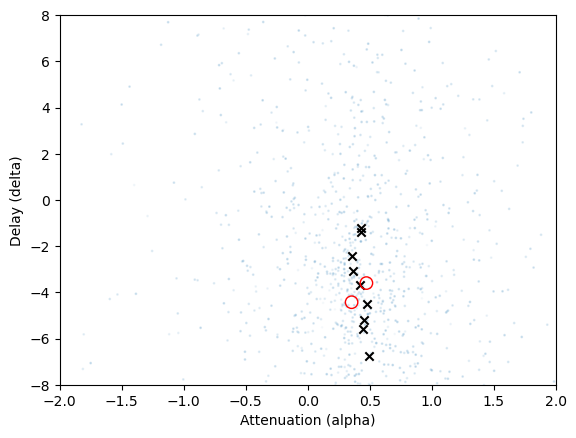

In [16]:
# Display visual results for a parameter set
param_i = scores_x_indices[0]
for i in range(len(DATA)):
    plt.figure()
    print(display_params(DATA[i], param_grid[param_i]))

In [211]:
grid

{'audio_length': [64, 80, 96, 112, 128, 144],
 'window': [64, 128, 256, 512, 1024],
 'oversample': [1],
 'threshold': [0.1, 0.25, 0.35],
 'bandwidth': [0.4, 0.75, 1.0],
 'alpha_max': [1.5],
 'delta_max': [8.5],
 'seed_count': [10, 20, 25],
 'min_bin_count': [1, 3],
 'convergence_tol': [0.25],
 'alpha_op': ['symmetric'],
 'big_delay': ['diff'],
 'delta_smoothing': [(1, 1), (3, 1), (3, 3), (5, 1), (5, 3)],
 'delta_smoothing_mode': ['mean']}

audio_length:
    doesn't seem to have any on time or score...? is it being used?
window:
    256 has the best, but 128 is also very good; 256 is slightly faster; 128 and 256 are quite good; 512 is worse
oversample:
    3 is always 3x slower than 1 and has significantly worse scores
threshold:
    higher thresholds are the fastest and have slightly better scores
bandwidth-alpha:
    bigger is faster; smaller produces smaller scores (although 0.1 is too small, 0.2 or 0.3 seem best)
bandwidth-delta:
    0.1-0.3 seem best; bigger is actually slower here
seed_count:
    lower seed counts are much faster, and are slightly better seems good; somewhere between 25 and 50 seems to be a good tradeoff
min_bin_count:
    between 1 and 5, possibly 5 is a bit better; should expand range
convergence_tol:
    barely any effect on score or time (between 0.05, 0.1, and 0.25)
big_delay:
    'diff' is definitely better (although not exclusively), even if it takes a bit longer
delta_smoothing:
    (1, 1) is worst, (3, 1) is best and doesn't take much longer, (3, 3) is in between in quality but takes longer
delta_smoothing_mode:
    'mean' is slightly worse but faster than 'median'
